<a href="https://colab.research.google.com/github/mrbedoya/ml-2026/blob/main/01_Preparaci%C3%B3nDataset01Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del dataset Analisis de creditos

https://data.mendeley.com/datasets/k9wszywskf/2

## 1. Librerias y configuraciones previas


In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Almacenar en caché los resultados de funciones en el disco
# ==============================================================================
import joblib

# Gestion de librerias
# ==============================================================================
from importlib import reload

# Matemáticas y estadísticas
# ==============================================================================
import math

# Preparación de datos
# ==============================================================================
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.neighbors import LocalOutlierFactor

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Interuactuar con os y solicitudes desde HTTP
# ==============================================================================
import os
import sys
import requests

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Parametros globales
# ==============================================================================

# URL base de GitHub para el repositorio
GITHUB_BASE_URL = 'https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/'

# Nombres de los archivos requeridos
DATASET_FILE_NAME = 'loan_approval_dataset.csv'
UTILS_FILE_NAME = 'funciones.py'

# Nombres de los directorios para utilidades, datasets y modelos
DATASETS_PATH = 'datasets/'
UTILS_PATH = 'utils/'
MODELS_PATH = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH = os.path.join(MODELS_PATH, 'scaler')

# URL completa del dataset y utils en GitHub
github_dataset_url = GITHUB_BASE_URL + DATASET_FILE_NAME
github_utils_url = GITHUB_BASE_URL + UTILS_FILE_NAME

# Rutas locales completas de datasets y utils
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path = os.path.join(UTILS_PATH, UTILS_FILE_NAME)

In [3]:
## Cargar datos desde Google Drive
## ==============================================================================

#from google.colab import drive

## Montar Google Drive
#drive.mount('/gdrive')

## Establece el directorio de trabajo dentro de directorio espefíficado en Google Drive
#os.chdir("/gdrive/MyDrive/01_Academia/02_Cursos/20260401_ApredinzajeAutomáticoI_UdeA/")

## Listar archivos de directorio
##!ls

In [4]:
# Funcion local para la carga de archivos
# ==============================================================================

def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.

    Args:
        url (str): URL del archivo
        path (str): Ruta local de destino
        description (str): Descripción del archivo
    Returns:
        None
    '''
    print(f"Descargando {description} desde: {url}")

    # Realiza una solicitud HTTP GET a la URL proporcionada
    response = requests.get(url)

    # Lanza una excepción si la descarga falla (código de estado HTTP no 200)
    response.raise_for_status()

    # Abre el archivo local en modo de escritura binaria ('wb')
    with open(path, 'wb') as f:
        # Escribe el contenido binario de la respuesta HTTP en el archivo local
        f.write(response.content)

    # Imprime un mensaje confirmando que la descarga fue exitosa y la ruta de guardado
    print(f"{description} descargado exitosamente a: {path}")

In [5]:
## Configuración entorno Colab
# ==============================================================================

# Creación de directorios locales
os.makedirs(DATASETS_PATH, exist_ok=True)
os.makedirs(UTILS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

# Crear subdirectorios específicos para modelos y escalados
os.makedirs(MODELS_CLASIFICACION_PATH, exist_ok=True)
os.makedirs(MODELS_SCALER_PATH, exist_ok=True)

# Descarga de archivos
download_file(github_dataset_url, local_dataset_path, "dataset")
download_file(github_utils_url, local_utils_path, "funciones")

Descargando dataset desde: https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/loan_approval_dataset.csv
dataset descargado exitosamente a: datasets/loan_approval_dataset.csv
Descargando funciones desde: https://raw.githubusercontent.com/Smartdvis17/Modelo_Analitica_Financiero/main/funciones.py
funciones descargado exitosamente a: utils/funciones.py


## 2. Funciones

In [6]:
## Funciones externas
# ==============================================================================

## Añade la ruta definida en 'UTILS_PATH' al 'sys.path' para que Python pueda encontrar módulos
sys.path.append(UTILS_PATH)

## Importa Funciones externas
from funciones import multiple_plot

## 3. Carga del dataset

Este dataset proviene de **Mendeley Data** y contiene información sobre solicitudes de
**préstamos bancarios en India**, incluyendo características financieras y demográficas
del solicitante. El objetivo es predecir si un préstamo será aprobado o rechazado.

Fuente original: https://data.mendeley.com/datasets/k9wszywskf/2

---

| Campo | Descripción | Ejemplo |
| :--- | :--- | :--- |
| `numero_dependientes` | Número de personas a cargo del solicitante | 2 |
| `educacion` | Nivel educativo: Graduate / Not Graduate | Graduate |
| `empleado` | ¿Trabaja por cuenta propia? Yes / No | No |
| `ingresos_anuales` | Ingresos anuales del solicitante (INR) | 9,600,000 |
| `monto_prestamo` | Monto del préstamo solicitado (INR) | 29,900,000 |
| `plazo_prestamo` | Plazo del préstamo en años | 12 |
| `puntaje_crediticio` | Score crediticio CIBIL (300–900) | 778 |
| `valor_activos_residenciales` | Valor de activos residenciales del solicitante (INR) | 2,400,000 |
| `valor_activos_comerciales` | Valor de activos comerciales del solicitante (INR) | 17,600,000 |
| `valor_activos_lujo` | Valor de activos de lujo del solicitante (INR) | 22,700,000 |
| `valor_activos_bancarios` | Valor de activos bancarios del solicitante (INR) | 8,000,000 |
| `estado_prestamo` | **Variable objetivo**: Approved / Rejected | Approved |

In [7]:
#Cargar el dataset
d = pd.read_csv(local_dataset_path)

In [8]:
#Creamos una copia del dataset
d_original = d.copy()

In [9]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [10]:
d = d.rename(columns={
    'loan_id': 'id_prestamo',
    ' no_of_dependents': 'numero_dependientes',
    ' education': 'educacion',
    ' self_employed': 'empleado',
    ' income_annum': 'ingresos_anuales',
    ' loan_amount': 'monto_prestamo',
    ' loan_term': 'plazo_prestamo',
    ' cibil_score': 'puntaje_crediticio',
    ' residential_assets_value': 'valor_activos_residenciales',
    ' commercial_assets_value': 'valor_activos_comerciales',
    ' luxury_assets_value': 'valor_activos_lujo',
    ' bank_asset_value': 'valor_activos_bancarios',
    ' loan_status': 'estado_prestamo'
})
d.head()

,id_prestamo,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [11]:
d.head(2)

,id_prestamo,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


## 4. Limpieza de datos (Data Cleaning)

In [12]:
#Borrando columnas que no se utilizarán

d.drop([ 'id_prestamo'], axis='columns', inplace=True)

In [13]:
#Limpiamos espacios al principio y final en variables categoricas
d = d.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [14]:
#Validar datos variables categoricas

print(d['educacion'].unique())
print(d['empleado'].unique())
print(d['estado_prestamo'].unique())

<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str
<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str


In [15]:
#Verificación y eliminación de registros duplicados

#Verificación de registros duplicados
d.loc[d.duplicated()]

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo


In [16]:
# eliminación de registros duplicados
d = d.drop_duplicates()

#Reiniciar el indice
d.reset_index(drop=True, inplace=True)

### Corrección: valor negativo en `valor_activos_residenciales`

Un activo residencial no puede tener valor negativo (financieramente imposible).
Se identifica y elimina el registro antes de continuar.

In [17]:
# CORRECCIÓN: eliminar registro con valor_activos_residenciales negativo
mask_neg = d['valor_activos_residenciales'] < 0
print(f'Registros con activos residenciales negativos: {mask_neg.sum()}')
if mask_neg.sum() > 0:
    print(d.loc[mask_neg, ['valor_activos_residenciales', 'estado_prestamo']])
    d = d[~mask_neg].reset_index(drop=True)
    print(f'Dataset tras limpieza: {d.shape}')

Registros con activos residenciales negativos: 28
      valor_activos_residenciales estado_prestamo
59                        -100000        Approved
196                       -100000        Approved
559                       -100000        Rejected
702                       -100000        Approved
737                       -100000        Rejected
784                       -100000        Approved
904                       -100000        Approved
1089                      -100000        Rejected
1163                      -100000        Approved
1350                      -100000        Rejected
1392                      -100000        Approved
1773                      -100000        Approved
1806                      -100000        Approved
1866                      -100000        Rejected
1933                      -100000        Rejected
1950                      -100000        Rejected
2707                      -100000        Approved
3019                      -100000        Rejected


In [18]:
d.head(2)

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


## 5. Visualización de datos

### Variables de entrada

In [19]:
#Lista de variables categóricas
catCols = d.select_dtypes(include = ["object", 'category']).columns.tolist()

d[catCols].head(2)

,educacion,empleado,estado_prestamo
0,Graduate,No,Approved
1,Not Graduate,Yes,Rejected


In [20]:
#Lista de variables numéricas

numCols=d.select_dtypes(include = ['float64','int32','int64']).columns.tolist()
d[numCols].head()

,numero_dependientes,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000


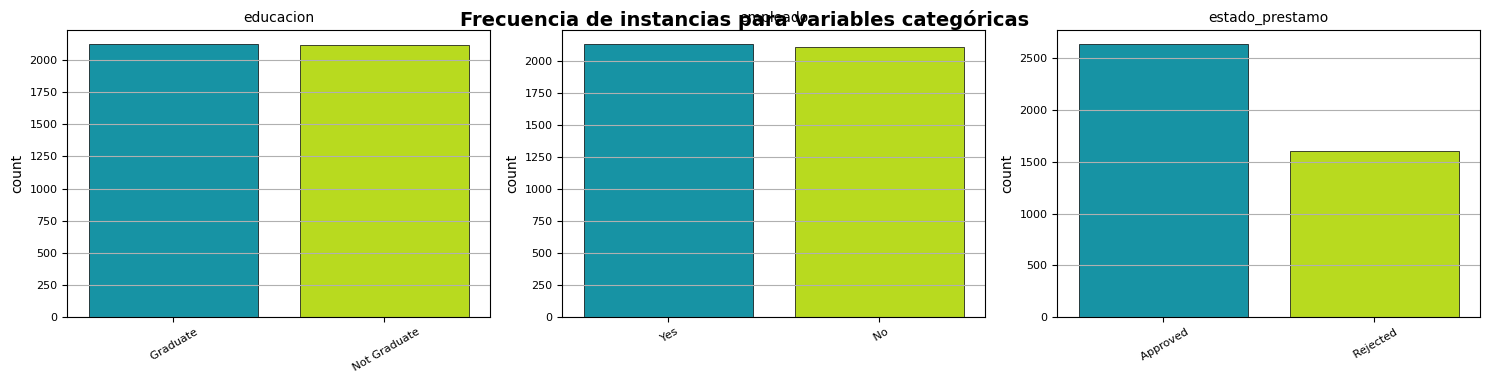

In [21]:
#Visualización de frecuencia de instancias para variables categóricas
multiple_plot(3, d , catCols, None, 'countplot', 'Frecuencia de instancias para variables categóricas',30)

### Distribución de Variables Categóricas con Porcentajes

A continuación, se visualiza la distribución de cada variable categórica, mostrando tanto el recuento como el porcentaje de cada categoría para una mejor interpretación.

In [22]:
# Distribución de cada variable categórica en el conjunto de datos

for col in catCols:
    print("="*5 + f" {col} " + "="*20)
    print(d[col].value_counts())
    print()

===== educacion ====================
educacion
Graduate        2127
Not Graduate    2114
Name: count, dtype: int64

===== empleado ====================
empleado
Yes    2135
No     2106
Name: count, dtype: int64

===== estado_prestamo ====================
estado_prestamo
Approved    2640
Rejected    1601
Name: count, dtype: int64




=== INTERPRETACIÓN DEL BOXPLOT ===
Este gráfico muestra la distribución del puntaje crediticio en función del estado del préstamo (Approved vs Rejected).

Interpretación de los componentes del gráfico:
- La línea central de cada caja representa la mediana del puntaje crediticio.
- La caja representa el rango intercuartílico (50% central de los datos).
- Los puntos extremos representan valores atípicos (outliers).

Análisis comparativo:
- Si la mediana de 'Approved' es mayor que la de 'Rejected', indica que los préstamos aprobados están asociados a mejores puntajes crediticios.
- Si las distribuciones se solapan, significa que el puntaje crediticio por sí solo no separa completamente las clases.
- Diferencias claras entre cajas indican que el puntaje crediticio es una variable relevante para la aprobación del préstamo.

Conclusión:
El puntaje crediticio es una variable clave en la decisión del estado del préstamo, ya que existe una diferencia en su distribución entre préstamos aprobado

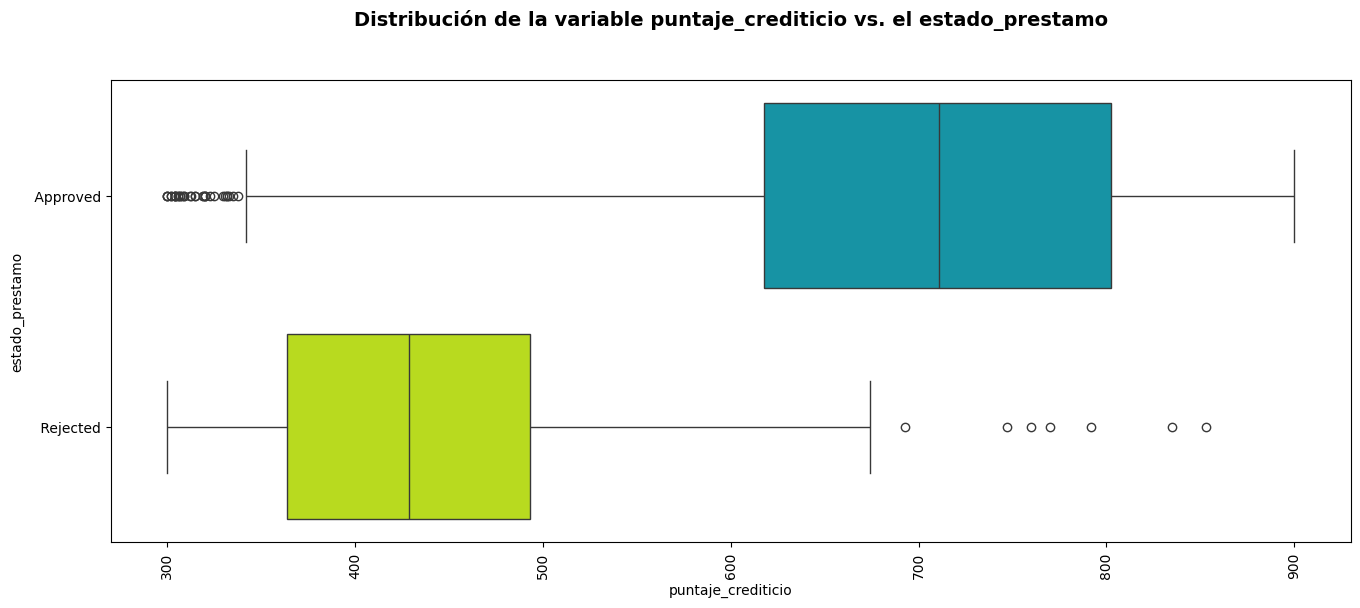

In [23]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
ax_cond = axes
sns.boxplot(data=d,
            x='puntaje_crediticio',
            y='estado_prestamo',
            ax=axes,
            palette='nipy_spectral',
            zorder=1
            )
# Personalizar el eje x
ax_cond.set_xticklabels(ax_cond.get_xticklabels(), rotation=90)
# Configurar título
ax_cond.set_title('Distribución de la variable puntaje_crediticio vs. el estado_prestamo', fontsize=14, fontweight="bold", y=1.1)

print("\n=== INTERPRETACIÓN DEL BOXPLOT ===")

print("Este gráfico muestra la distribución del puntaje crediticio en función del estado del préstamo (Approved vs Rejected).")

print("\nInterpretación de los componentes del gráfico:")
print("- La línea central de cada caja representa la mediana del puntaje crediticio.")
print("- La caja representa el rango intercuartílico (50% central de los datos).")
print("- Los puntos extremos representan valores atípicos (outliers).")

print("\nAnálisis comparativo:")

print("- Si la mediana de 'Approved' es mayor que la de 'Rejected', indica que los préstamos aprobados están asociados a mejores puntajes crediticios.")
print("- Si las distribuciones se solapan, significa que el puntaje crediticio por sí solo no separa completamente las clases.")
print("- Diferencias claras entre cajas indican que el puntaje crediticio es una variable relevante para la aprobación del préstamo.")

print("\nConclusión:")

print("El puntaje crediticio es una variable clave en la decisión del estado del préstamo, ya que existe una diferencia en su distribución entre préstamos aprobados y rechazados.")

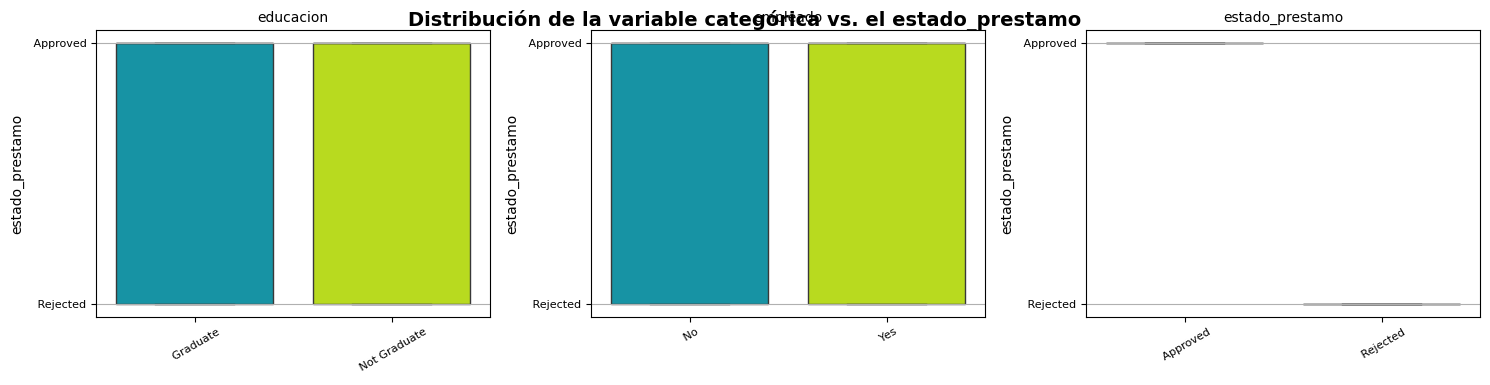

In [24]:
multiple_plot(3, d , catCols, 'estado_prestamo', 'boxplot', 'Distribución de la variable categórica vs. el estado_prestamo',30)

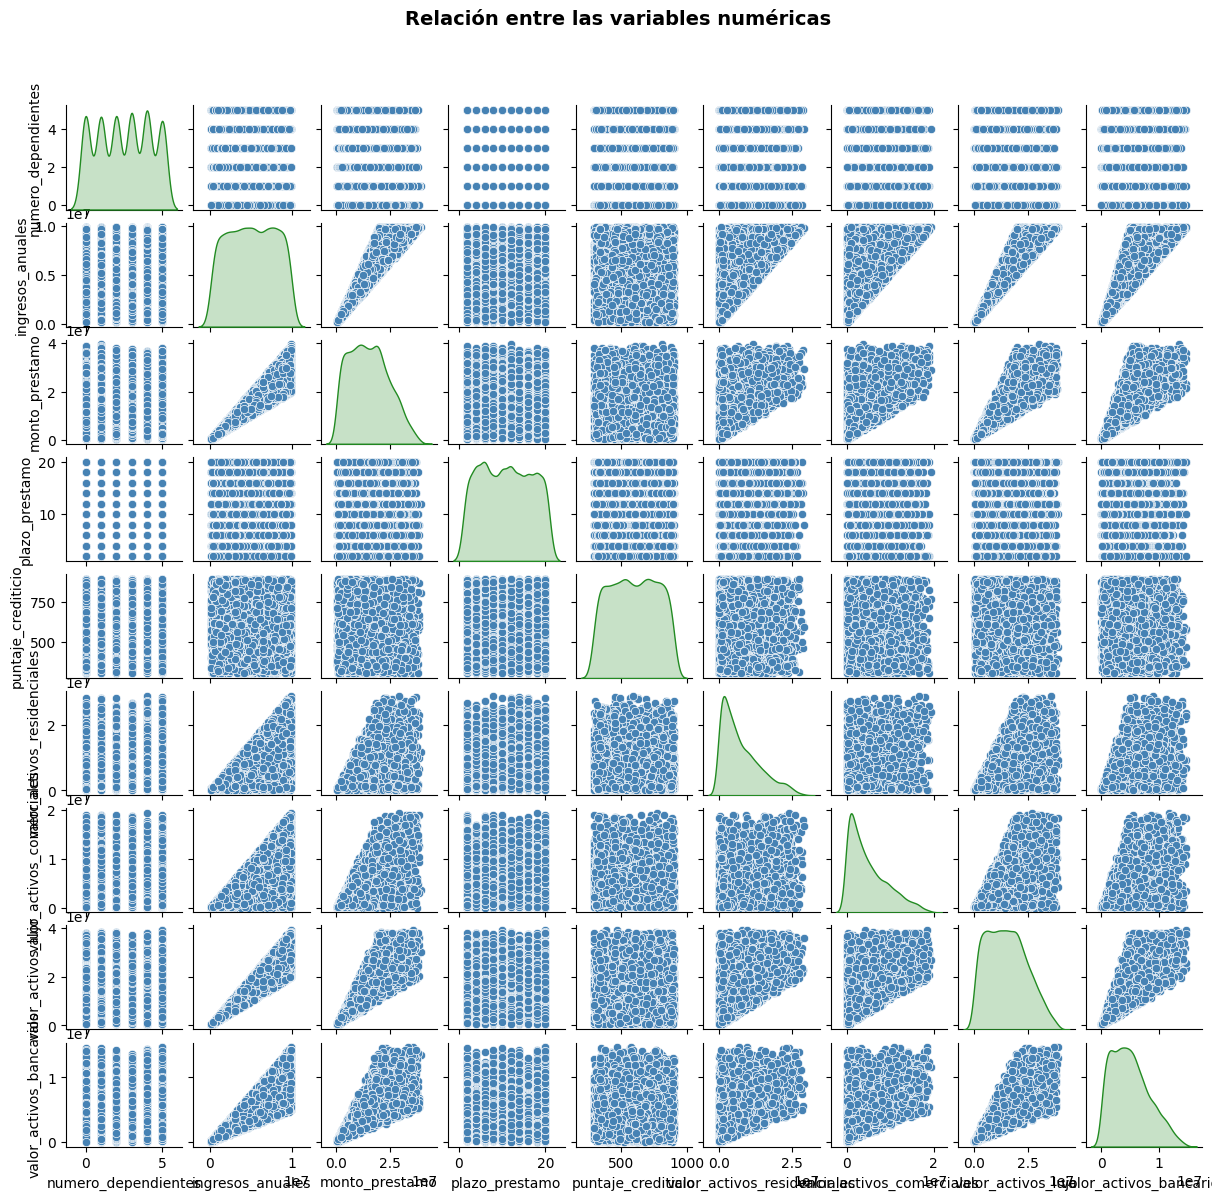

In [25]:
#Visualización de variables numéricas con respecto al precio
multiple_plot(1, d , numCols, None, 'scatterplot', 'Relación entre las variables numéricas',30)

### Variable de salida

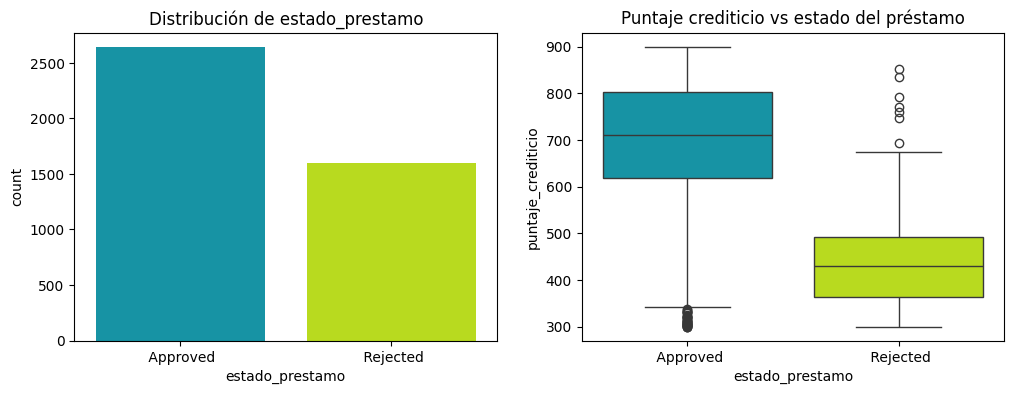

In [26]:
plt.figure(figsize=(12,4))

# 1) distribución
plt.subplot(1,2,1)
plt.title('Distribución de estado_prestamo')
sns.countplot(x='estado_prestamo', data=d, palette='nipy_spectral')

# 2) DIFERENCIAS reales en puntaje crediticio entre préstamos aprobados y rechazados
plt.subplot(1,2,2)
plt.title('Puntaje crediticio vs estado del préstamo')
sns.boxplot(x='estado_prestamo', y='puntaje_crediticio', data=d, palette='nipy_spectral')

plt.show()

In [27]:
d['estado_prestamo'].value_counts()

estado_prestamo
Approved    2640
Rejected    1601
Name: count, dtype: int64

In [28]:
d['estado_prestamo'].value_counts(normalize=True) * 100

estado_prestamo
Approved    62.249469
Rejected    37.750531
Name: proportion, dtype: float64

## 6. Preparación de datos

### Distribución y balance de la variable de salida (`estado_prestamo`)

Para clasificación es fundamental verificar el balance entre clases. 

=== Balance de la variable objetivo ===
  Rejected ( Approved): 2640 registros (62.2%)
  Rejected ( Rejected): 1601 registros (37.8%)

Ratio mayoritaria/minoritaria: 1.65
Desbalance moderado. Usar class_weight="balanced" en el modelo.


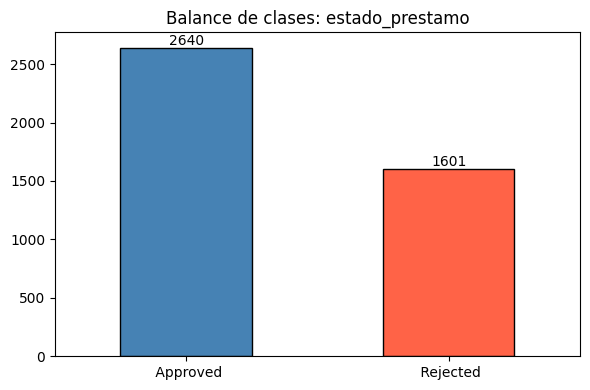

In [29]:
# Análisis de balance de clases
conteo = d['estado_prestamo'].value_counts()
prop = d['estado_prestamo'].value_counts(normalize=True).mul(100).round(1)

print('=== Balance de la variable objetivo ===')
for estado, n in conteo.items():
    label = 'Approved' if estado == 1 else 'Rejected'
    print(f'  {label} ({estado}): {n} registros ({prop[estado]}%)')

ratio = conteo.max() / conteo.min()
print(f'\nRatio mayoritaria/minoritaria: {ratio:.2f}')

if ratio > 3:
    print('ALERTA: desbalance severo. Considerar SMOTE o class_weight.')
elif ratio > 1.5:
    print('Desbalance moderado. Usar class_weight="balanced" en el modelo.')
else:
    print('Balance aceptable. No se requiere corrección especial.')

# Visualización
fig, ax = plt.subplots(figsize=(6, 4))
conteo.rename({1: 'Approved', 0: 'Rejected'}).plot(
    kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black'
)
ax.set_title('Balance de clases: estado_prestamo')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Verificación de valores nulos e imputaciones

Se verifica que no existan valores nulos en ninguna variable. Al no encontrarse,
no se requiere imputación. A continuación también se realiza el **encoding**
de las variables categóricas binarias usando mapeo directo.

In [30]:
#Identificación de valores nulos para las variables numéricas
for col in d[numCols]:
    print (col, np.sum(pd.isnull(d[col])))

numero_dependientes 0
ingresos_anuales 0
monto_prestamo 0
plazo_prestamo 0
puntaje_crediticio 0
valor_activos_residenciales 0
valor_activos_comerciales 0
valor_activos_lujo 0
valor_activos_bancarios 0


In [31]:
#Identificación de valores nulos para las variables categorica
for col in d[catCols]:
    print (col, np.sum(pd.isnull(d[col])))

educacion 0
empleado 0
estado_prestamo 0


In [32]:
#Validar datos variables categoricas
print(d["educacion"].unique())
print(d["empleado"].unique())
print(d["estado_prestamo"].unique())

# strip() elimina espacios al inicio/fin que trae el dataset crudo
d["educacion"]      = d["educacion"].str.strip().map({"Graduate": 1, "Not Graduate": 0})
d["empleado"]       = d["empleado"].str.strip().map({"Yes": 1, "No": 0})
d["estado_prestamo"]= d["estado_prestamo"].str.strip().map({"Approved": 1, "Rejected": 0})

print("Despues del encoding:")
print(d[["educacion","empleado","estado_prestamo"]].head())

<StringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str
<StringArray>
[' No', ' Yes']
Length: 2, dtype: str
<StringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str
Despues del encoding:
   educacion  empleado  estado_prestamo
0          1         0                1
1          0         1                0
2          1         0                0
3          1         0                0
4          0         1                0


In [33]:
#Integración de los dos dataframes (categoricos y numéricos) después de la imputación

d.head()

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,valor_activos_residenciales,valor_activos_comerciales,valor_activos_lujo,valor_activos_bancarios,estado_prestamo
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [34]:
#verificación de la imputación: No existen valores nulos
for col in d.columns:
    print (col, np.sum(pd.isnull(d[col])))

numero_dependientes 0
educacion 0
empleado 0
ingresos_anuales 0
monto_prestamo 0
plazo_prestamo 0
puntaje_crediticio 0
valor_activos_residenciales 0
valor_activos_comerciales 0
valor_activos_lujo 0
valor_activos_bancarios 0
estado_prestamo 0


### Valores atípicos para las variables de entrada

### Detección de valores atípicos 

**Corrección metodológica:** LOF es un algoritmo basado en distancias y es
sensible a las escalas de las variables. Sin normalizar, las variables de mayor
magnitud (activos, ingresos, hasta 39M) dominan el cálculo, mientras
`puntaje_crediticio` (rango 600) y `numero_dependientes` (rango 5) tienen
influencia casi nula.

**Solución:** se aplica `StandardScaler` únicamente para LOF. Los datos originales
(`d`) no se modifican en esta etapa.

In [35]:
from sklearn.preprocessing import StandardScaler

# Escalar SOLO para LOF (no modifica el dataframe original)
scaler_lof = StandardScaler()
X_scaled_lof = scaler_lof.fit_transform(d[numCols])

# LocalOutlierFactor sobre datos escalados
# n_neighbors=20: más robusto que 13 para n~4000 (rango recomendado: 20-50)
# contamination=0.1: se asume que hasta el 10% podría ser atípico
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X_scaled_lof)

outliers = y_pred == -1
print(f'Total registros: {len(d)}')
print(f'Outliers detectados: {outliers.sum()} ({outliers.mean()*100:.1f}%)')
print(f'Registros limpios: {(~outliers).sum()}')

Total registros: 4241
Outliers detectados: 424 (10.0%)
Registros limpios: 3817


In [36]:
# Eliminar los valores atípicos del dataframe original
d = d.loc[~outliers]

### Transformaciones

In [37]:
d['total_activos'] = (
    d['valor_activos_residenciales'] +
    d['valor_activos_comerciales'] +
    d['valor_activos_lujo'] +
    d['valor_activos_bancarios']
)

### Análisis de multicolinealidad — VIF

Se creó `total_activos` como suma de los cuatro activos individuales, pero ambos
conjuntos coexisten en el dataset. Esto genera **colinealidad casi exacta**.
Se aplica el Factor de Inflación de la Varianza (VIF) para cuantificarlo
y se resuelve eliminando las columnas individuales de activos.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Columnas para verificar multicolinealidad
cols_vif = ['numero_dependientes', 'ingresos_anuales', 'monto_prestamo',
            'plazo_prestamo', 'puntaje_crediticio',
            'valor_activos_residenciales', 'valor_activos_comerciales',
            'valor_activos_lujo', 'valor_activos_bancarios', 'total_activos']

X_vif = d[cols_vif].copy()
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF antes de resolver multicolinealidad ===')
print(vif_data.round(2))
print()
print('Regla: VIF > 10 indica multicolinealidad problemática')
print('VIF > 5 merece revisión; VIF > 100 indica colinealidad casi exacta')

# CORRECCIÓN: eliminar columnas individuales de activos
# Se conserva 'total_activos' como variable agregada más compacta
cols_eliminar = ['valor_activos_residenciales', 'valor_activos_comerciales',
                 'valor_activos_lujo', 'valor_activos_bancarios']
d = d.drop(columns=cols_eliminar)
print(f'\nColumnas eliminadas: {cols_eliminar}')
print(f'Variables restantes: {list(d.columns)}')

=== VIF antes de resolver multicolinealidad ===
                      Variable    VIF
0      valor_activos_bancarios    inf
1  valor_activos_residenciales    inf
2                total_activos    inf
3    valor_activos_comerciales    inf
4           valor_activos_lujo    inf
5             ingresos_anuales  75.21
6               monto_prestamo  29.19
7           puntaje_crediticio   6.23
8               plazo_prestamo   4.16
9          numero_dependientes   2.95

Regla: VIF > 10 indica multicolinealidad problemática
VIF > 5 merece revisión; VIF > 100 indica colinealidad casi exacta

Columnas eliminadas: ['valor_activos_residenciales', 'valor_activos_comerciales', 'valor_activos_lujo', 'valor_activos_bancarios']
Variables restantes: ['numero_dependientes', 'educacion', 'empleado', 'ingresos_anuales', 'monto_prestamo', 'plazo_prestamo', 'puntaje_crediticio', 'estado_prestamo', 'total_activos']


In [39]:
# Discretización (binning) de 'puntaje_crediticio' en rangos de riesgo crediticio
# Rangos basados en la escala CIBIL estándar usada por bancos en India:
#   300-499: Riesgo Alto   | 500-649: Riesgo Medio | 650-749: Aceptable | 750-900: Excelente

bins = [299, 499, 649, 749, 900]
labels = ['Alto_Riesgo', 'Medio_Riesgo', 'Aceptable', 'Excelente']

d['categoria_crediticia'] = pd.cut(
    d['puntaje_crediticio'],
    bins=bins,
    labels=labels,
    right=True
)

print('=== Distribución de categorías crediticias ===')
print(d['categoria_crediticia'].value_counts().sort_index())
print()

# Tasa de aprobación por categoría (validación del poder discriminante)
print('=== Tasa de aprobación por categoría crediticia ===')
tasa = d.groupby('categoria_crediticia', observed=True)['estado_prestamo'].mean().mul(100).round(1)
for cat, t in tasa.items():
    print(f'  {cat}: {t}% aprobados')

# Encoding ordinal de la nueva variable categórica
orden_riesgo = {'Alto_Riesgo': 0, 'Medio_Riesgo': 1, 'Aceptable': 2, 'Excelente': 3}
d['categoria_crediticia'] = d['categoria_crediticia'].map(orden_riesgo)
print('\nEncoding ordinal aplicado (0=Alto Riesgo ... 3=Excelente)')
print(d[['puntaje_crediticio', 'categoria_crediticia']].head(8))

=== Distribución de categorías crediticias ===
categoria_crediticia
Alto_Riesgo     1228
Medio_Riesgo     986
Aceptable        690
Excelente        913
Name: count, dtype: int64

=== Tasa de aprobación por categoría crediticia ===
  Alto_Riesgo: 10.1% aprobados
  Medio_Riesgo: 67.1% aprobados
  Aceptable: 99.4% aprobados
  Excelente: 99.6% aprobados

Encoding ordinal aplicado (0=Alto Riesgo ... 3=Excelente)
   puntaje_crediticio categoria_crediticia
0                 778                    3
1                 417                    0
2                 506                    1
3                 467                    0
4                 382                    0
5                 319                    0
7                 382                    0
8                 782                    3


In [40]:
d.head()

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,estado_prestamo,total_activos,categoria_crediticia
0,2,1,0,9600000,29900000,12,778,1,50700000,3
1,0,0,1,4100000,12200000,8,417,0,17000000,0
2,3,1,0,9100000,29700000,20,506,0,57700000,1
3,3,1,0,8200000,30700000,8,467,0,52700000,0
4,5,0,1,9800000,24200000,20,382,0,55000000,0


### Datos de prueba

In [41]:
# CORRECCIÓN: Split estratificado para respetar distribución de clases
# Error anterior: muestreo aleatorio simple no garantiza misma proporción
# de Approved/Rejected en ambos conjuntos (importante con desbalance).

from sklearn.model_selection import train_test_split

df, dp = train_test_split(
    d,
    test_size=0.10,
    random_state=123,
    stratify=d['estado_prestamo']  # estratificado por clase objetivo
)

df = df.reset_index(drop=True)
dp = dp.reset_index(drop=True)

print(f'Entrenamiento: {df.shape}')
print(f'Prueba:        {dp.shape}')

# Verificar que la distribución de clases se preservó
prop_df = df['estado_prestamo'].value_counts(normalize=True).mul(100).round(1)
prop_dp = dp['estado_prestamo'].value_counts(normalize=True).mul(100).round(1)
print(f'\nProporción Approved en entrenamiento: {prop_df.get(1, 0)}%')
print(f'Proporción Approved en prueba:         {prop_dp.get(1, 0)}%')
print('Estratificación exitosa: proporciones similares en ambos conjuntos.')

Entrenamiento: (3435, 10)
Prueba:        (382, 10)

Proporción Approved en entrenamiento: 62.4%
Proporción Approved en prueba:         62.3%
Estratificación exitosa: proporciones similares en ambos conjuntos.


In [42]:
dp.shape

(382, 10)

## 7. Exportar el dataset

### Normalización para el modelo

Se aplica `StandardScaler` a las variables numéricas antes de exportar.
El scaler se ajusta **solo con el conjunto de entrenamiento** (df) y luego
se aplica a ambos (df y dp) para evitar *data leakage*.
El objeto scaler se guarda en disco para usarlo en producción.

In [43]:
from sklearn.preprocessing import StandardScaler

# Variables a escalar (excluir target y variables binarias/ordinales)
cols_escalar = ['ingresos_anuales', 'monto_prestamo', 'plazo_prestamo',
                'puntaje_crediticio', 'total_activos']

scaler = StandardScaler()

# Ajustar SOLO con entrenamiento para evitar data leakage
df[cols_escalar] = scaler.fit_transform(df[cols_escalar])
dp[cols_escalar] = scaler.transform(dp[cols_escalar])

# Guardar el scaler para uso en producción/inferencia
joblib.dump(scaler, MODELS_SCALER_PATH + '/scaler_loan.pkl')
print(f'Scaler guardado en: {MODELS_SCALER_PATH}/scaler_loan.pkl')

print('\nEstadísticos post-escalado (entrenamiento):')
print(df[cols_escalar].describe().round(3))

Scaler guardado en: modelos/scaler/scaler_loan.pkl

Estadísticos post-escalado (entrenamiento):
       ingresos_anuales  monto_prestamo  plazo_prestamo  puntaje_crediticio  \
count          3435.000        3435.000        3435.000            3435.000   
mean             -0.000          -0.000          -0.000              -0.000   
std               1.000           1.000           1.000               1.000   
min              -1.701          -1.626          -1.619              -1.793   
25%              -0.865          -0.833          -0.900              -0.843   
50%               0.007          -0.062           0.179              -0.018   
75%               0.843           0.719           0.899               0.849   
max               1.824           2.724           1.618               1.794   

       total_activos  
count       3435.000  
mean           0.000  
std            1.000  
min           -1.625  
25%           -0.840  
50%           -0.051  
75%            0.744  
max     

In [44]:
# Exportamos el dataframe a un archivo CSV
df.to_csv(DATASETS_PATH + 'loan_approval_dataset_Prep.csv', index=False)
dp.to_csv(DATASETS_PATH + 'loan_approval_dataset_Prue.csv', index=False)

In [45]:
df.head(10)

,numero_dependientes,educacion,empleado,ingresos_anuales,monto_prestamo,plazo_prestamo,puntaje_crediticio,estado_prestamo,total_activos,categoria_crediticia
0,2,0,1,1.242819,0.673882,0.179274,0.771619,1,2.072722,2
1,0,1,0,-1.228431,-1.172607,0.179274,1.202058,1,-1.075785,3
2,4,1,0,0.734033,0.005521,-1.619230,-0.621329,0,0.362486,0
3,5,0,0,-0.974037,-0.844091,-0.180426,-0.406110,0,-1.018254,1
4,4,0,1,1.460871,1.410211,1.258377,-1.416445,0,1.251599,0
5,0,1,0,-1.119405,-1.002685,1.258377,-1.506120,0,-1.060095,0
6,1,0,0,-1.410140,-1.274560,1.258377,-0.131107,1,-1.284988,1
7,1,0,0,-0.646960,-0.912060,1.618078,1.417277,1,-0.354034,3
8,4,0,1,-0.247199,-0.572215,1.618078,1.572713,1,-0.563237,3
9,1,0,1,1.061110,0.855132,-0.180426,0.974882,1,0.676291,3


### Referencias

- *Dataset:*
    - https://data.mendeley.com/datasets/k9wszywskf/2
    - Mirror Kaggle: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

- *LocalOutlierFactor:*
    - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html

- *StandardScaler:*
    - https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

- *VIF — Variance Inflation Factor:*
    - https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html

- *Estratificación en train_test_split:*
    - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

- *CIBIL Score rangos:*
    - https://www.cibil.com/faq/what-is-a-good-cibil-score

- *scikit-learn:*
    - https://scikit-learn.org/stable/user_guide.html